In [4]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-factitial-dermatitis-1.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/v-eczema-areola-13.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-eczema-subacute-66.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-eczema-hand-86.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-keratolysis-exfoliativa-17.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-lichen-simplex-chronicus-136.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-eczema-subacute-60.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-fissure-11.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-Dyshidrosis-36.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/t-Dyshidrosis-55.jpg
/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/1. Ecz

# To ensure GPU availability

In [1]:
import tensorflow as tf

# List GPUs available
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"CUDA is available. GPU device name: {gpus[0].name}")
    
    # Set memory growth to prevent TensorFlow from allocating all GPU memory
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

    # Use the first GPU by default
    with tf.device('/GPU:0'):
        # Your code (model training, inference, etc.)
        pass
else:
    print("CUDA is not available.")

CUDA is available. GPU device name: /physical_device:GPU:0


# Importing necessary libraries

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Keras imports
from keras.models import Sequential, Model
from keras.optimizers import Adam
from keras.applications import EfficientNetB7
from keras.callbacks import ReduceLROnPlateau
from keras.utils import image_dataset_from_directory
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

# Updated ImageDataGenerator import
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

# Sklearn imports
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# General imports
import random
import keras

import shutil

# Copy the data to working directory

In [3]:
# Define paths
data_path = '/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES'
output_path = '/kaggle/working/Skin-disease-images'


# Remove the existing dataset from the working directory if it exists
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Copy the dataset to a writable directory
if not os.path.exists(output_path):
    shutil.copytree(data_path, output_path)

# Checking Class distribution

Class counts:
1. Eczema 1677: 1677
10. Warts Molluscum and other Viral Infections - 2103: 2103
2. Melanoma 15.75k: 3140
3. Atopic Dermatitis - 1.25k: 1257
4. Basal Cell Carcinoma (BCC) 3323: 3323
5. Melanocytic Nevi (NV) - 7970: 7970
6. Benign Keratosis-like Lesions (BKL) 2624: 2079
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702


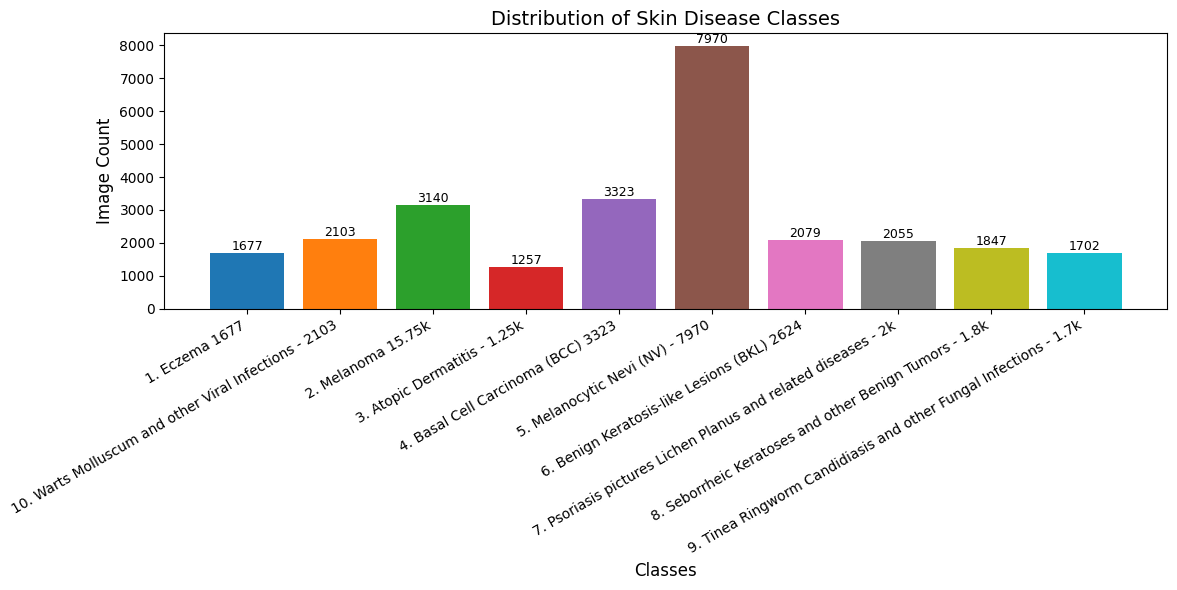

In [4]:
import os
import matplotlib.pyplot as plt

# Use the copied dataset
classes = sorted(os.listdir(output_path))  # sort alphabetically for consistency
class_counts = [len(os.listdir(os.path.join(output_path, x))) for x in classes]

print("Class counts:")
for c, count in zip(classes, class_counts):
    print(f"{c}: {count}")

# Visualize class counts
plt.figure(figsize=(12, 6))
bars = plt.bar(classes, class_counts, color=plt.cm.tab10.colors)

plt.xlabel('Classes', fontsize=12)
plt.ylabel('Image Count', fontsize=12)
plt.title('Distribution of Skin Disease Classes', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)  # rotate labels for clarity
plt.tight_layout()

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,  # small offset above the bar
        f'{height}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()


# Oversampling and Undersampling

In [5]:
from PIL import Image
import numpy as np

# Oversampler function
def oversampler(class_name, class_count, target=7000, batch_size=32, target_size=(240, 240)):
    # Initialize the ImageDataGenerator with augmentation settings
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.15,
        zoom_range=0.15,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    curr_dir = os.path.join(output_path, class_name)
    save_dir = curr_dir

    # Load images from the current class folder
    images = os.listdir(curr_dir)
    images = [os.path.join(curr_dir, img) for img in images]

    cnt = class_count
    target = target
    
    # Loop over images in batches, apply augmentation, and save them
    while cnt < target:
        batch_images = []
        
        # Load and resize images to the target size before converting to NumPy array
        for img_path in random.sample(images, batch_size):
            img = Image.open(img_path).convert('RGB')
            img = img.resize(target_size)  # Resize the image
            img = np.array(img)  # Convert the PIL image to a NumPy array
            batch_images.append(img)

        batch_images = np.array(batch_images)  # Convert the list of images to a NumPy array

        # Process and augment the batch of images
        for _ in datagen.flow(batch_images, batch_size=batch_size, save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
            cnt += batch_size
            if cnt >= target:
                break
        
        print(f"Processed {cnt}/{target} images for {class_name}")

# Undersampler function
def undersampler(class_name, class_count, target_count=7000):
    curr_dir = os.path.join(output_path, class_name)
    images = os.listdir(curr_dir)

    # Calculate the number of images to delete
    images_to_delete = random.sample(images, class_count - target_count)

    # Delete images in batches
    for image in images_to_delete:
        img_path = os.path.join(curr_dir, image)
        try:
            os.remove(img_path)
        except Exception as e:
            print(f"Error deleting {img_path}: {e}")

    print(f"Deleted {len(images_to_delete)} images for {class_name}")

In [6]:
# Oversample or undersample each class
for i, class_name in enumerate(classes):
    if class_counts[i] < 7000:
        oversampler(class_name, class_counts[i])
    else:
        undersampler(class_name, class_counts[i])

print("Oversampling and undersampling completed successfully.")

Processed 7021/7000 images for 1. Eczema 1677
Processed 7031/7000 images for 10. Warts Molluscum and other Viral Infections - 2103
Processed 7012/7000 images for 2. Melanoma 15.75k
Processed 7017/7000 images for 3. Atopic Dermatitis - 1.25k
Processed 7003/7000 images for 4. Basal Cell Carcinoma (BCC) 3323
Deleted 970 images for 5. Melanocytic Nevi (NV) - 7970
Processed 7007/7000 images for 6. Benign Keratosis-like Lesions (BKL) 2624
Processed 7015/7000 images for 7. Psoriasis pictures Lichen Planus and related diseases - 2k
Processed 7031/7000 images for 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
Processed 7014/7000 images for 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
Oversampling and undersampling completed successfully.


# Checking class imbalance

Class counts per class:
1. Eczema 1677: 6990
10. Warts Molluscum and other Viral Infections - 2103: 6997
2. Melanoma 15.75k: 6988
3. Atopic Dermatitis - 1.25k: 6976
4. Basal Cell Carcinoma (BCC) 3323: 6976
5. Melanocytic Nevi (NV) - 7970: 7000
6. Benign Keratosis-like Lesions (BKL) 2624: 6964
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 6981
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 6989
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 6977


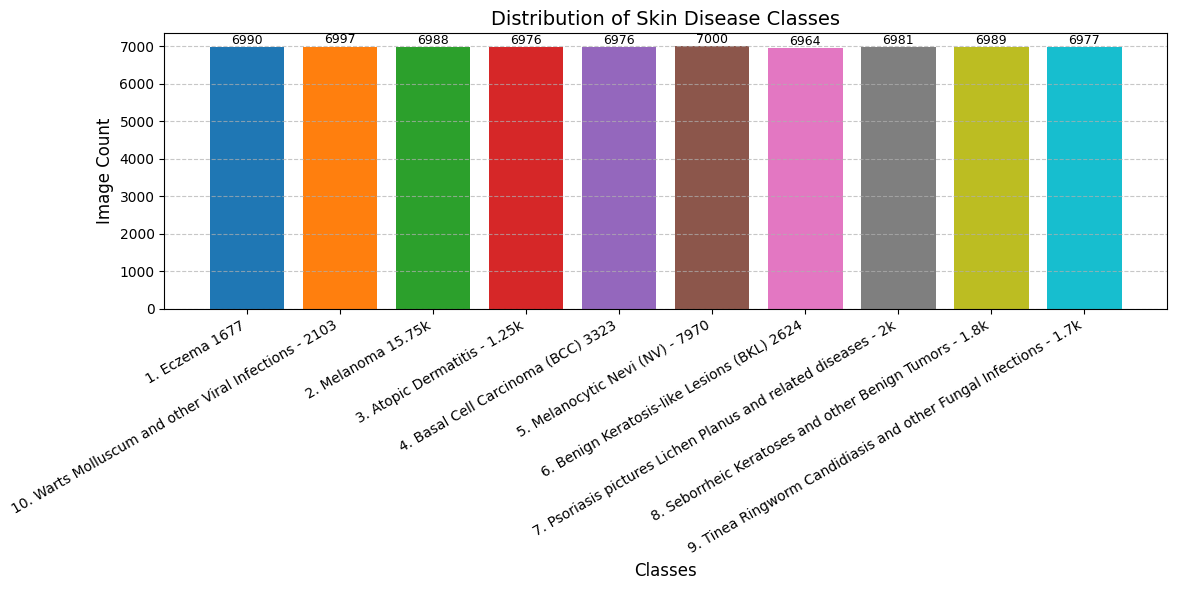

In [7]:
import os
import matplotlib.pyplot as plt

# Get class names and image counts
classes = sorted(os.listdir(output_path))
class_counts = [len(os.listdir(os.path.join(output_path, x))) for x in classes]

# Print class counts for reference
print("Class counts per class:")
for c, count in zip(classes, class_counts):
    print(f"{c}: {count}")

# Plot the class distribution
plt.figure(figsize=(12, 6))
bars = plt.bar(classes, class_counts, color=plt.cm.tab10.colors)

plt.xlabel('Classes', fontsize=12)
plt.ylabel('Image Count', fontsize=12)
plt.title('Distribution of Skin Disease Classes', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,  # offset above the bar
        f'{height}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()


# Train and Test Split

In [8]:
import os
import random
import shutil

# Define paths for training, validation, and testing datasets
train_path = '/kaggle/working/train'
val_path = '/kaggle/working/val'
test_path = '/kaggle/working/test'

# Create directories for each dataset split
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Set the split ratios for train, validation, and test datasets
train_ratio = 0.7  # 70% for training
val_ratio = 0.15   # 15% for validation
test_ratio = 0.15  # 15% for testing

# Loop over each class in the output dataset and split it
for class_folder in os.listdir(output_path):  # using the output_path where dataset resides
    class_path = os.path.join(output_path, class_folder)
    
    # Create class directories in train, val, and test folders
    train_class_path = os.path.join(train_path, class_folder)
    val_class_path = os.path.join(val_path, class_folder)
    test_class_path = os.path.join(test_path, class_folder)
    
    os.makedirs(train_class_path, exist_ok=True)
    os.makedirs(val_class_path, exist_ok=True)
    os.makedirs(test_class_path, exist_ok=True)
    
    # List and shuffle the images in the current class folder
    images = os.listdir(class_path)
    random.shuffle(images)
    num_images = len(images)
    
    # Split the images based on the defined ratios
    num_train = int(num_images * train_ratio)
    num_val = int(num_images * val_ratio)
    num_test = num_images - num_train - num_val
    
    # Allocate images to each split
    train_images = images[:num_train]
    val_images = images[num_train:num_train + num_val]
    test_images = images[num_train + num_val:]
    
    # Copy images to the appropriate directories
    for image in train_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(train_class_path, image))
    
    for image in val_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(val_class_path, image))
    
    for image in test_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(test_class_path, image))

print("Dataset split completed successfully.")

Dataset split completed successfully.


# Loading Images

In [9]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Define image size and batch size
img_size = (256, 256)
batch_size = 32

# Paths to train and validation datasets (as defined in the previous steps)
train_path = '/kaggle/working/train'
val_path = '/kaggle/working/val'

# Create the train dataset
train_dataset = image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=123
)

# Get the class names from the training dataset
class_names = train_dataset.class_names

# Create the validation dataset
val_dataset = image_dataset_from_directory(
    val_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=123
)

# Display class names (optional)
print("Class Names:", class_names)

Found 48882 files belonging to 10 classes.
Found 10472 files belonging to 10 classes.
Class Names: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


# Preprocessing the data

In [10]:
import tensorflow as tf
# Preprocessing function
@tf.function
def preprocess_image(image, label):
    # Resize the image
    image = tf.image.resize(image, [256, 256])
    # Apply EfficientNet preprocessing
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

# Apply the preprocessing pipeline to the datasets
train_dataset = train_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

# Model Building

In [11]:
from tensorflow.keras.layers import (
    Dense, BatchNormalization, Dropout, GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers import Adam

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(256, 256, 3)
)

# Freeze base model for initial training
for layer in base_model.layers:
    layer.trainable = False

inputs = Input(shape=(256, 256, 3))
x = base_model(inputs, training=False)  # Prevents BatchNorm updates
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 8, 8, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       1,311,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,026,157 (22.99 MB)

 Trainable params: 1,973,514 (7.53 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

# Train the model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
# Define early stopping and learning rate reduction callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train model
epochs = 50
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stopping, lr_reduction]
)

Epoch 1/50
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 149s 81ms/step - accuracy: 0.6528 - loss: 0.9878 - val_accuracy: 0.8681 - val_loss: 0.3704 - learning_rate: 0.0010
Epoch 2/50
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 97s 64ms/step - accuracy: 0.8402 - loss: 0.4446 - val_accuracy: 0.8854 - val_loss: 0.3089 - learning_rate: 0.0010
Epoch 3/50
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 98s 64ms/step - accuracy: 0.8603 - loss: 0.3847 - val_accuracy: 0.8927 - val_loss: 0.2902 - learning_rate: 0.0010
Epoch 4/50
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 98s 64ms/step - accuracy: 0.8714 - loss: 0.3480 - val_accuracy: 0.8947 - val_loss: 0.2812 - learning_rate: 0.0010
Epoch 5/50
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 97s 63ms/step - accuracy: 0.8820 - loss: 0.3215 - val_accuracy: 0.8996 - val_loss: 0.2751 - learning_rate: 0.0010
Epoch 6/50
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 97s 64ms/step - accuracy: 0.8923 - loss: 0.2967 - val_accuracy: 0.8969 - val_loss: 0.2743 - learning_rate: 0.0010
Epoch 7/50
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 97s 64ms/step - accur

# Saving the model

In [13]:
# Save the model after training
model_save_path = '/kaggle/working/my_model.h5'
model.save(model_save_path)

# Optionally, display a message confirming the model is saved
print(f'Model saved at {model_save_path}')

Model saved at /kaggle/working/my_model.h5


Found 10484 files belonging to 10 classes.

✅ Test Accuracy: 91.71%

Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.89      0.91      0.90      1049
           10. Warts Molluscum and other Viral Infections - 2103       0.90      0.89      0.90      1051
                                              2. Melanoma 15.75k       0.97      0.96      0.97      1049
                                    3. Atopic Dermatitis - 1.25k       0.92      0.92      0.92      1047
                              4. Basal Cell Carcinoma (BCC) 3323       0.92      0.95      0.93      1047
                                 5. Melanocytic Nevi (NV) - 7970       0.91      0.94      0.92      1050
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.94      0.89      0.92      1046
   7. Psoriasis pictures Lichen Planus and related disease

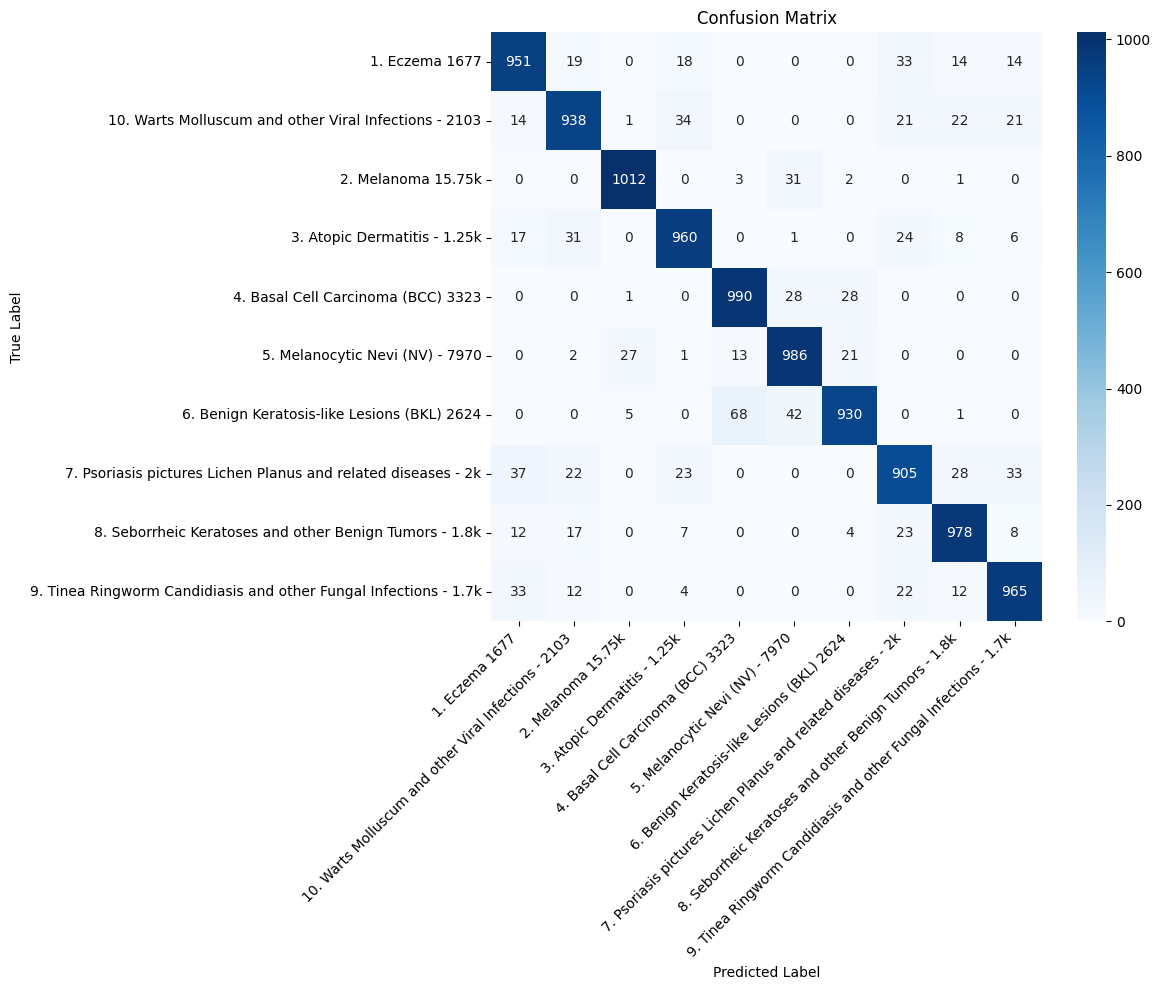

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing import image_dataset_from_directory

# --- 1. Load test dataset (no shuffle to maintain order)
raw_test_dataset = image_dataset_from_directory(
    '/kaggle/working/test',
    image_size=(256, 256),
    batch_size=32,
    shuffle=False
)

# --- 2. Get class names
class_names = raw_test_dataset.class_names

# --- 3. Preprocessing function (consistent with training)
@tf.function
def preprocess_image(image, label):
    image = tf.image.resize(image, [256, 256])
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

# --- 4. Apply preprocessing + prefetch
test_dataset = raw_test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

# --- 5. Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- 6. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%\n")

# --- 7. Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- 8. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- 1. Unfreeze deeper layers for fine-tuning
for layer in model.layers[-100:]:  # Unfreeze last 100 layers
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# --- 2. Recompile with a *lower learning rate* for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 3. Set up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# --- 4. Fine-tune the model
fine_tune_epochs = 20

history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=fine_tune_epochs,
    callbacks=[early_stopping, lr_reduction]
)


Epoch 1/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 135s 76ms/step - accuracy: 0.9406 - loss: 0.1665 - val_accuracy: 0.9159 - val_loss: 0.2490 - learning_rate: 1.0000e-05
Epoch 2/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 99s 65ms/step - accuracy: 0.9423 - loss: 0.1636 - val_accuracy: 0.9155 - val_loss: 0.2481 - learning_rate: 1.0000e-05
Epoch 3/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 99s 65ms/step - accuracy: 0.9432 - loss: 0.1587 - val_accuracy: 0.9155 - val_loss: 0.2481 - learning_rate: 1.0000e-05
Epoch 4/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 142s 64ms/step - accuracy: 0.9439 - loss: 0.1583 - val_accuracy: 0.9160 - val_loss: 0.2487 - learning_rate: 1.0000e-05
Epoch 5/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 98s 64ms/step - accuracy: 0.9445 - loss: 0.1605 - val_accuracy: 0.9153 - val_loss: 0.2485 - learning_rate: 1.0000e-05
Epoch 6/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 98s 64ms/step - accuracy: 0.9459 - loss: 0.1534 - val_accuracy: 0.9154 - val_loss: 0.2487 - learning_rate: 2.0000e-06
Epoch 7/20
1527/1528 ━━━━━━━━━━━━━━━━━

In [16]:
finemodel_save_path = '/kaggle/working/finetuned_model.h5'
model.save(finemodel_save_path)

# Optionally, display a message confirming the model is saved
print(f'Model saved at {finemodel_save_path}')

Model saved at /kaggle/working/finetuned_model.h5


Found 10484 files belonging to 10 classes.

✅ Test Accuracy: 91.90%

Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.91      0.90      0.91      1049
           10. Warts Molluscum and other Viral Infections - 2103       0.89      0.91      0.90      1051
                                              2. Melanoma 15.75k       0.97      0.96      0.97      1049
                                    3. Atopic Dermatitis - 1.25k       0.93      0.91      0.92      1047
                              4. Basal Cell Carcinoma (BCC) 3323       0.92      0.95      0.94      1047
                                 5. Melanocytic Nevi (NV) - 7970       0.90      0.94      0.92      1050
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.95      0.89      0.92      1046
   7. Psoriasis pictures Lichen Planus and related disease

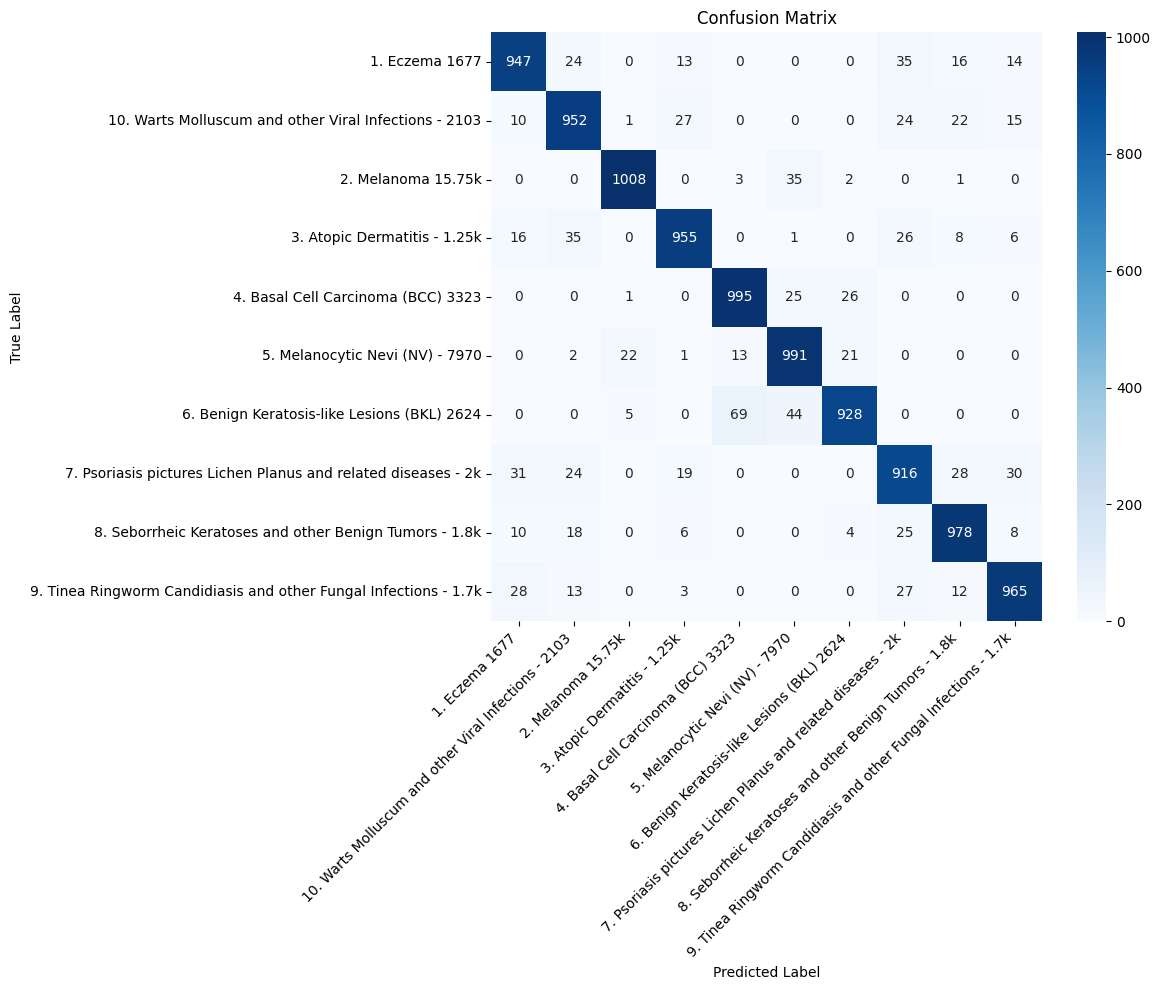

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing import image_dataset_from_directory

# --- 1. Load test dataset (no shuffle to maintain order)
raw_test_dataset = image_dataset_from_directory(
    '/kaggle/working/test',
    image_size=(256, 256),
    batch_size=32,
    shuffle=False
)

# --- 2. Get class names
class_names = raw_test_dataset.class_names

# --- 3. Preprocessing function (consistent with training)
@tf.function
def preprocess_image(image, label):
    image = tf.image.resize(image, [256, 256])
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

# --- 4. Apply preprocessing + prefetch
test_dataset = raw_test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

# --- 5. Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- 6. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%\n")

# --- 7. Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- 8. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()





In [19]:
!zip -r test_dataset.zip /kaggle/working/test

  adding: kaggle/working/test/ (stored 0%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/ (stored 0%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/aug_25_162.jpg (deflated 2%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/aug_12_5698.jpg (deflated 1%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/aug_4_342.jpg (deflated 1%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/t-epidermal-cyst-160.jpg (deflated 0%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/t-skin-tags-polyps-64.jpg (deflated 1%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/t-keratoacanthoma-98.jpg (deflated 0%)
  adding: kaggle/working/test/8. Seborrheic Keratoses and other Benign Tumors - 1.8k/aug_16_8342.jpg (deflated 2%)
  adding: kaggle/working/test